Compute the physical length of each road segment in meters, and assign an estimated speed (km/h) based on its highway type.

Field workers will know the fastest route to drive on by the land cover type. A dirst road will take longer than a paved highway.

Travel time = distance / speed = km divided by km/hour = hours to travel

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Load your saved metric dataset directly
file_path = r"C:\Users\308ca\Desktop\Amazonia\Data\combined_roads_paragominas_metric_units.geojson"
print(f"Loading dataset from: {file_path}")
combined_gdf_meters = gpd.read_file(file_path)

Loading dataset from: C:\Users\308ca\Desktop\Amazonia\Data\combined_roads_paragominas_metric_units.geojson


In [3]:
combined_gdf_meters.head(10)

,osm_id,highway,surface,nome,ref,tracktype,source,cat,fonte,road_group,geometry
0,31484259.0,trunk,NaN,Belém-Brasília,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (890707.829 9654954.643, 890870.372..."
1,31484266.0,trunk,asphalt,Rodovia Belém-Brasília,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (889292.355 9584999.365, 889321.847..."
2,31484273.0,trunk,NaN,Belém-Brasília,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (891613.601 9658817.906, 891633.022..."
3,31484274.0,trunk,NaN,Belém-Brasília,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (893710.563 9695695.139, 893670.072..."
4,31484287.0,trunk,NaN,Rodovia Bernardo Sayão,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (892734.807 9635751.038, 892603.575..."
5,31484293.0,trunk,NaN,Rodovia Bernardo Sayão,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (892402.815 9637431, 892323.013 963..."
6,31484305.0,trunk,asphalt,Avenida Juscelino Kubitschek,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (889911.252 9717094.542, 889923.436..."
7,31484308.0,trunk,asphalt,Rodovia Bernardo Sayão,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (890194.688 9608669.9, 890268.92 96..."
8,31484309.0,trunk,NaN,Belém-Brasília,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (895555 9685347.729, 895469.494 968..."
9,31484327.0,trunk,asphalt,Belém-Brasília,BR-010,NaN,OSM (Official Roads),NaN,NaN,Paved / Main Roads,"LINESTRING (893088.126 9665006.453, 893095.139..."


In [4]:
# 2. Define the operational speeds in km/h 
highway_speeds = {
    'primary': 80.0,
    'secondary': 60.0,
    'tertiary': 45.0,
    'residential': 30.0,
    'unclassified': 25.0,
    'track': 15.0,
    'path': 10.0,
    'service': 20.0,
    'motorway': 90.0
}

In [5]:
# 3. Function to assign speed based on the highway tag
def get_routing_speed(highway_type):
    # Default to 15 km/h if an unknown tag shows up
    return highway_speeds.get(str(highway_type).lower(), 15.0)

combined_gdf_meters['speed_kmh'] = combined_gdf_meters['highway'].apply(get_routing_speed)

In [6]:
# 4. Calculate edge length in meters and derive travel time in hours
# Time (hours) = Distance (meters) / Speed (meters per hour)
combined_gdf_meters['length_meters'] = combined_gdf_meters.geometry.length
combined_gdf_meters['travel_time_hours'] = combined_gdf_meters['length_meters'] / (combined_gdf_meters['speed_kmh'] * 1000)

In [7]:
print("Speeds and travel-time weights successfully calculated!")
print(combined_gdf_meters)
print(combined_gdf_meters[['source', 'highway', 'speed_kmh', 'length_meters', 'travel_time_hours']])

Speeds and travel-time weights successfully calculated!
           osm_id       highway  surface                    nome     ref  \
0      31484259.0         trunk      NaN          Belém-Brasília  BR-010   
1      31484266.0         trunk  asphalt  Rodovia Belém-Brasília  BR-010   
2      31484273.0         trunk      NaN          Belém-Brasília  BR-010   
3      31484274.0         trunk      NaN          Belém-Brasília  BR-010   
4      31484287.0         trunk      NaN  Rodovia Bernardo Sayão  BR-010   
...           ...           ...      ...                     ...     ...   
42881         NaN  unclassified      NaN                     NaN     NaN   
42882         NaN  unclassified      NaN                     NaN     NaN   
42883         NaN  unclassified      NaN                     NaN     NaN   
42884         NaN  unclassified      NaN                     NaN     NaN   
42885         NaN  unclassified      NaN                     NaN     NaN   

      tracktype                

Plot data for some information for workers.

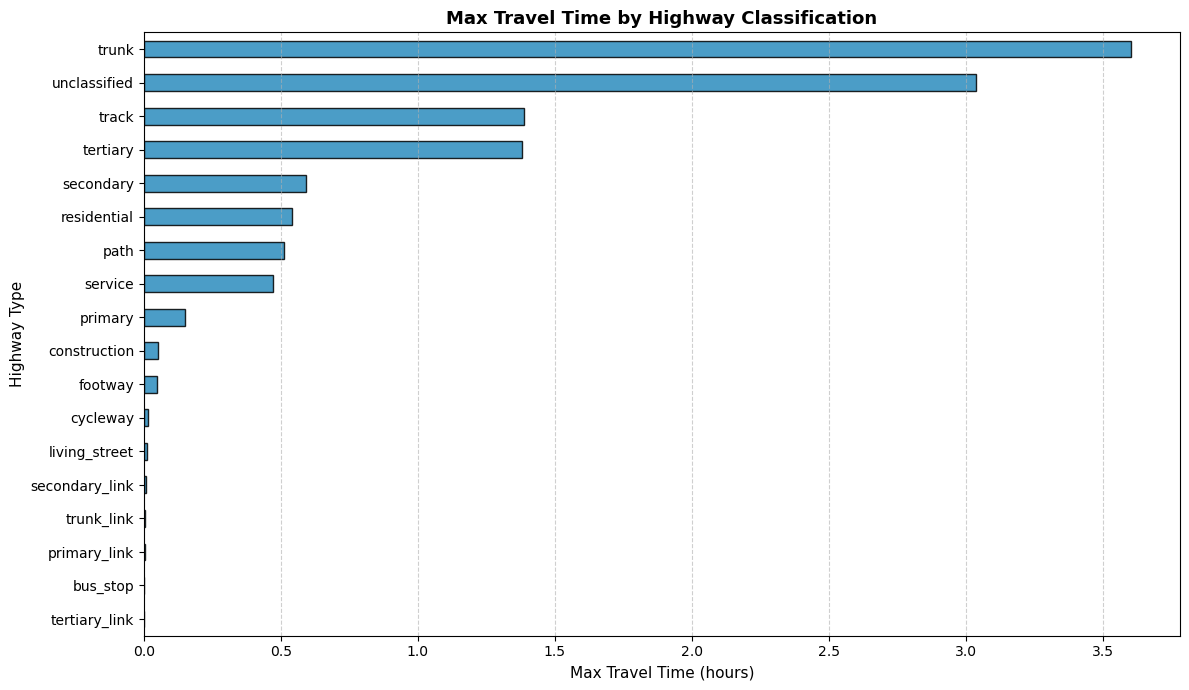

In [8]:
# Group by highway type and calculate the average travel time
max_time_by_highway = combined_gdf_meters.groupby('highway')['travel_time_hours'].max().sort_values()

# Create a horizontal bar graph
plt.figure(figsize=(12, 7))
bars = max_time_by_highway.plot(
    kind='barh', 
    color='#2b8cbe', 
    edgecolor='black', 
    alpha=0.85
)

plt.xlabel('Max Travel Time (hours)', fontsize=11)
plt.ylabel('Highway Type', fontsize=11)
plt.title('Max Travel Time by Highway Classification', fontsize=13, fontweight='bold')

# Clean grid lines on the x-axis
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Max_Travel_Time_by_Highway_Type.png')
plt.show()

In [9]:
# 5. Save the clean processed dataset for the upcoming NetworkX graph step
output_filename = "combined_roads_paragominas_with_travel_time.geojson"
print(f"Saving combined dataset to {output_filename}...")
combined_gdf_meters.to_file(output_filename, driver="GeoJSON")
print("Dataset saved successfully.")

Saving combined dataset to combined_roads_paragominas_with_travel_time.geojson...
Dataset saved successfully.
